# Academic Advisor — Results Analysis

Loads trained artifacts from `models/` and presents evaluation results. **No training happens here.**

In [ ]:
from pathlib import Path
import json, io, contextlib, re

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import precision_score, recall_score, f1_score

from src.model_training import (
    MODEL_FEATURES, CATEGORICAL_FEATURES,
    prepare_X_y, learn_categorical_levels,
    evaluate_pass, evaluate_grade,
    stratified_eval_pass,
    print_threshold_table, stratified_threshold_table,
    _THRESHOLDS,
)
from src.paths import MODELS_DIR, MODEL_DATA_DIR

# ── Paths ────────────────────────────────────────────────────────────
TRAIN_PATH = MODEL_DATA_DIR / "df_train_final.parquet"
VALID_PATH = MODEL_DATA_DIR / "df_valid_final.parquet"
TEST_PATH = MODEL_DATA_DIR / "df_test_final.parquet"

# ── Data ────────────────────────────────────────────────────────────
df_train = pd.read_parquet(TRAIN_PATH)
df_valid = pd.read_parquet(VALID_PATH)
df_test = pd.read_parquet(TEST_PATH)
print(f"train {df_train.shape}  valid {df_valid.shape}  test {df_test.shape}")

# Re-derive categorical levels from train only — mirrors what training does.
categorical_levels = learn_categorical_levels(df_train)

# ── Trained boosters ──────────────────────────────────────────────────
m1 = lgb.Booster(model_file=str(MODELS_DIR / "m1_pass_model.lgbm"))
m2 = lgb.Booster(model_file=str(MODELS_DIR / "m2_grade_model.lgbm"))

# ── JSON artifacts ────────────────────────────────────────────────────
metrics = json.loads((MODELS_DIR / "metrics.json").read_text())
training_curves = json.loads((MODELS_DIR / "training_curves.json").read_text())
feature_contract = json.loads((MODELS_DIR / "feature_contract.json").read_text())

print("All artifacts loaded.")

---
## M1 — Pass/Fail Classifier Overview

Re-evaluates M1 on all splits using the same `evaluate_pass` function used during training; rows = split, columns = metrics.

In [7]:
m1_results = {}
for split, df_split in [("train", df_train), ("valid", df_valid), ("test", df_test)]:
    m1_results[split] = evaluate_pass(m1, df_split, categorical_levels)

overview_cols = ["auc", "avg_precision", "accuracy",
                 "precision", "recall", "f1",
                 "fail_precision", "fail_recall", "fail_f1", "brier"]

m1_overview = pd.DataFrame(
    {split: {k: m1_results[split][k] for k in overview_cols}
     for split in ["train", "valid", "test"]}
).T
m1_overview.index.name = "split"
m1_overview

,auc,avg_precision,accuracy,precision,recall,f1,fail_precision,fail_recall,fail_f1,brier
split,,,,,,,,,,
train,0.9058,0.9765,0.8886,0.8860,0.9957,0.9377,0.9335,0.3208,0.4775,0.0826
valid,0.7808,0.9677,0.8897,0.8986,0.9885,0.9414,0.2515,0.0334,0.0589,0.0863
test,0.7689,0.9701,0.8991,0.9117,0.9846,0.9467,0.1636,0.0306,0.0516,0.0796


---
## M1 — Confusion Matrices

Confusion matrix at threshold=0.5 for each split (rows=actual, cols=predicted); sourced from `evaluate_pass` output above.

In [8]:
for split in ["train", "valid", "test"]:
    cm = m1_results[split]["confusion_matrix"]
    df_cm = pd.DataFrame(
        [[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]],
        index=pd.Index(["Actual FAIL", "Actual PASS"], name=split),
        columns=["Pred FAIL", "Pred PASS"],
    )
    display(df_cm)
    print()

,Pred FAIL,Pred PASS
train,,
Actual FAIL,22932,48550
Actual PASS,1633,377350


,Pred FAIL,Pred PASS
valid,,
Actual FAIL,539,15608
Actual PASS,1604,138346


,Pred FAIL,Pred PASS
test,,
Actual FAIL,302,9553
Actual PASS,1544,98609


---
## M1 — Stratified Segment Breakdown

AUC by student segment on the test set — surfaces model blind spots for edge groups.

In [9]:
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    stratified_eval_pass(m1, df_test, categorical_levels)

rows = []
for line in buf.getvalue().splitlines():
    line = line.strip()
    m = re.match(r'\[(\w+)\]\s+n=([\d,]+)\s+AUC=(.+)', line)
    if not m:
        continue
    seg, n_str, auc_str = m.group(1), m.group(2), m.group(3).strip()
    n_int = int(n_str.replace(",", ""))
    try:
        auc_val, note = round(float(auc_str), 4), ""
    except ValueError:
        auc_val, note = None, auc_str
    rows.append({"segment": seg, "n": n_int, "AUC": auc_val, "note": note})

pd.DataFrame(rows).set_index("segment")

,n,AUC,note
segment,,,
first_semester,15447,0.5520,
retake_attempt,9093,0.6473,
low_difficulty_support,34699,0.7547,
cold_start_gpa,15447,0.5520,


---
## M1 — Threshold Tables

Fail-class precision / recall / F1 across decision thresholds; select threshold on valid, verify consistency on test.

In [10]:
rows = []
for split_label, df_split in [("train", df_train), ("valid", df_valid), ("test", df_test)]:
    X, y = prepare_X_y(df_split, "pass", categorical_levels)
    y_prob = m1.predict(X)
    for thr in _THRESHOLDS:
        y_bin = (y_prob >= thr).astype(int)
        rows.append({
            "split":    split_label,
            "threshold": thr,
            "fail_P":   round(precision_score(y, y_bin, pos_label=0, zero_division=0), 4),
            "fail_R":   round(recall_score(y, y_bin, pos_label=0, zero_division=0), 4),
            "fail_F1":  round(f1_score(y, y_bin, pos_label=0, zero_division=0), 4),
        })

thr_df = pd.DataFrame(rows)
thr_df

,split,threshold,fail_P,fail_R,fail_F1
0,train,0.3,1.0000,0.0406,0.0780
1,train,0.4,0.9987,0.1183,0.2115
2,train,0.5,0.9335,0.3208,0.4775
3,train,0.6,0.8215,0.5140,0.6323
4,train,0.7,0.6930,0.6734,0.6831
5,valid,0.3,0.0635,0.0012,0.0023
6,valid,0.4,0.1345,0.0066,0.0125
7,valid,0.5,0.2515,0.0334,0.0589
8,valid,0.6,0.2830,0.0851,0.1308
9,valid,0.7,0.3052,0.2082,0.2476


---
## M1 — Segmented Threshold Table

Same fail-class threshold sweep broken down by test-set segments — descriptive only, no threshold is auto-selected.

In [11]:
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    stratified_threshold_table(m1, df_test, categorical_levels)

output = buf.getvalue()
seg_tables = {}
current_seg, current_rows = None, []

for line in output.splitlines():
    seg_m  = re.match(r'\s+\[(\w+)\]\s+n=([\d,]+)', line)
    data_m = re.match(r'\s+(0\.\d)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', line)
    if seg_m:
        if current_seg:
            seg_tables[current_seg] = pd.DataFrame(current_rows)
        current_seg  = seg_m.group(1)
        current_rows = []
    elif data_m and current_seg:
        current_rows.append({
            "threshold": float(data_m.group(1)),
            "fail_P":    float(data_m.group(2)),
            "fail_R":    float(data_m.group(3)),
            "fail_F1":   float(data_m.group(4)),
        })

if current_seg:
    seg_tables[current_seg] = pd.DataFrame(current_rows)

for seg, df_seg in seg_tables.items():
    print(f"\n--- {seg} ---")
    display(df_seg.set_index("threshold"))


--- first_semester ---


,fail_P,fail_R,fail_F1
threshold,,,
0.3,0.0497,0.0105,0.0173
0.4,0.1062,0.0529,0.0707
0.5,0.1188,0.0983,0.1076
0.6,0.1031,0.1262,0.1135
0.7,0.1222,0.1943,0.1500



--- retake_attempt ---


,fail_P,fail_R,fail_F1
threshold,,,
0.3,0.0000,0.0000,0.0000
0.4,0.3030,0.0043,0.0086
0.5,0.4009,0.0404,0.0734
0.6,0.3925,0.1355,0.2014
0.7,0.3748,0.3561,0.3652



--- low_difficulty_support ---


,fail_P,fail_R,fail_F1
threshold,,,
0.3,0.0000,0.0000,0.0000
0.4,0.0000,0.0000,0.0000
0.5,0.3333,0.0009,0.0019
0.6,0.4061,0.0211,0.0401
0.7,0.3187,0.1215,0.1760



--- cold_start_gpa ---


,fail_P,fail_R,fail_F1
threshold,,,
0.3,0.0497,0.0105,0.0173
0.4,0.1062,0.0529,0.0707
0.5,0.1188,0.0983,0.1076
0.6,0.1031,0.1262,0.1135
0.7,0.1222,0.1943,0.1500


---
## M1 — Threshold Plot

Visual version of the threshold table — valid (left) and test (right) side by side.

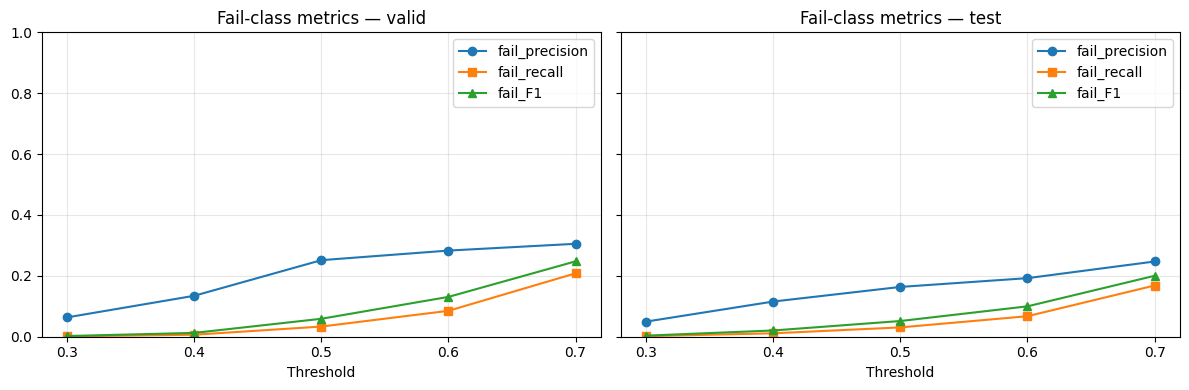

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (split_label, df_split) in zip(axes, [("valid", df_valid), ("test", df_test)]):
    X, y = prepare_X_y(df_split, "pass", categorical_levels)
    y_prob = m1.predict(X)
    fps, frs, ffs = [], [], []
    for thr in _THRESHOLDS:
        y_bin = (y_prob >= thr).astype(int)
        fps.append(precision_score(y, y_bin, pos_label=0, zero_division=0))
        frs.append(recall_score(y, y_bin, pos_label=0, zero_division=0))
        ffs.append(f1_score(y, y_bin, pos_label=0, zero_division=0))
    ax.plot(_THRESHOLDS, fps, marker="o", label="fail_precision")
    ax.plot(_THRESHOLDS, frs, marker="s", label="fail_recall")
    ax.plot(_THRESHOLDS, ffs, marker="^", label="fail_F1")
    ax.set_title(f"Fail-class metrics — {split_label}")
    ax.set_xlabel("Threshold")
    ax.set_xticks(_THRESHOLDS)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## M2 — Final Mark Regressor Overview

Re-evaluates M2 on all splits; a large train–valid gap in MAE signals overfitting.

In [ ]:
m2_results = {}
for split, df_split in [("train", df_train), ("valid", df_valid), ("test", df_test)]:
    m2_results[split] = evaluate_grade(m2, df_split, categorical_levels)

m2_overview = pd.DataFrame(m2_results).T
m2_overview.index.name = "split"
m2_overview

---
## M2 — Training Curve

MAE vs boosting iteration for train / valid / test; red dashed line = early-stopped iteration on valid.

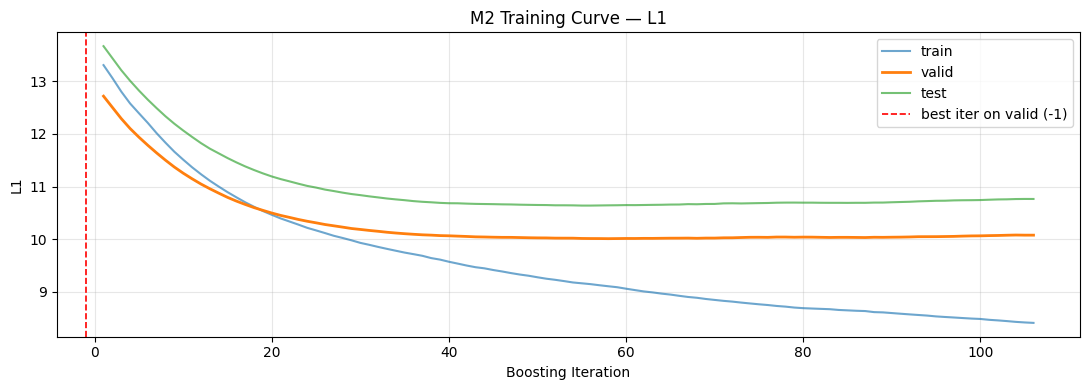

In [13]:
m2_tc      = training_curves["m2_grade_regressor"]
metric_m2  = m2_tc["metric"]
n_rounds   = len(m2_tc["valid"])
iters      = list(range(1, n_rounds + 1))
best_m2    = m2.best_iteration

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(iters, m2_tc["train"], label="train", alpha=0.65)
ax.plot(iters, m2_tc["valid"], label="valid",  linewidth=2)
ax.plot(iters, m2_tc["test"],  label="test",   alpha=0.65)
ax.axvline(best_m2, color="red", linestyle="--", linewidth=1.2,
           label=f"best iter on valid ({best_m2})")
ax.set_xlabel("Boosting Iteration")
ax.set_ylabel(metric_m2.upper())
ax.set_title(f"M2 Training Curve — {metric_m2.upper()}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## M1 — Training Curve

AUC vs boosting iteration for train / valid / test; red dashed line = early-stopped iteration on valid.

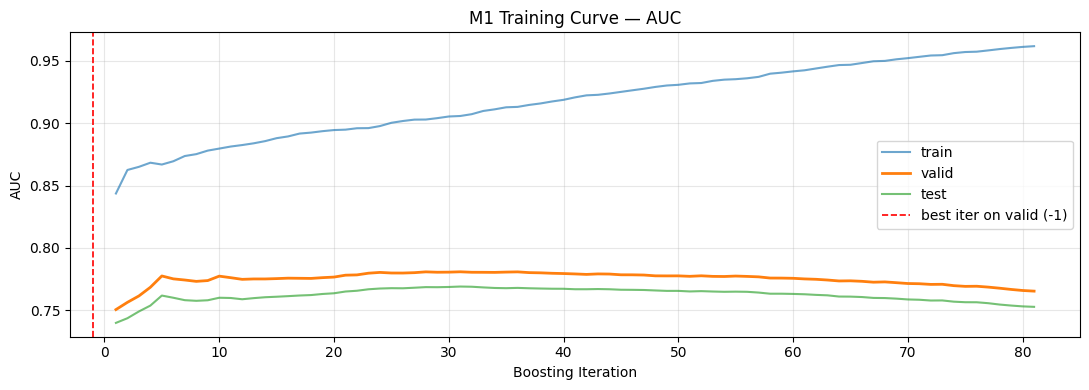

In [14]:
m1_tc      = training_curves["m1_pass_classifier"]
metric_m1  = m1_tc["metric"]
n_rounds   = len(m1_tc["valid"])
iters      = list(range(1, n_rounds + 1))
best_m1    = m1.best_iteration

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(iters, m1_tc["train"], label="train", alpha=0.65)
ax.plot(iters, m1_tc["valid"], label="valid",  linewidth=2)
ax.plot(iters, m1_tc["test"],  label="test",   alpha=0.65)
ax.axvline(best_m1, color="red", linestyle="--", linewidth=1.2,
           label=f"best iter on valid ({best_m1})")
ax.set_xlabel("Boosting Iteration")
ax.set_ylabel(metric_m1.upper())
ax.set_title(f"M1 Training Curve — {metric_m1.upper()}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Feature Importance

Top 15 features by gain for M1 and M2 — gain reflects total split improvement, more meaningful than split count.

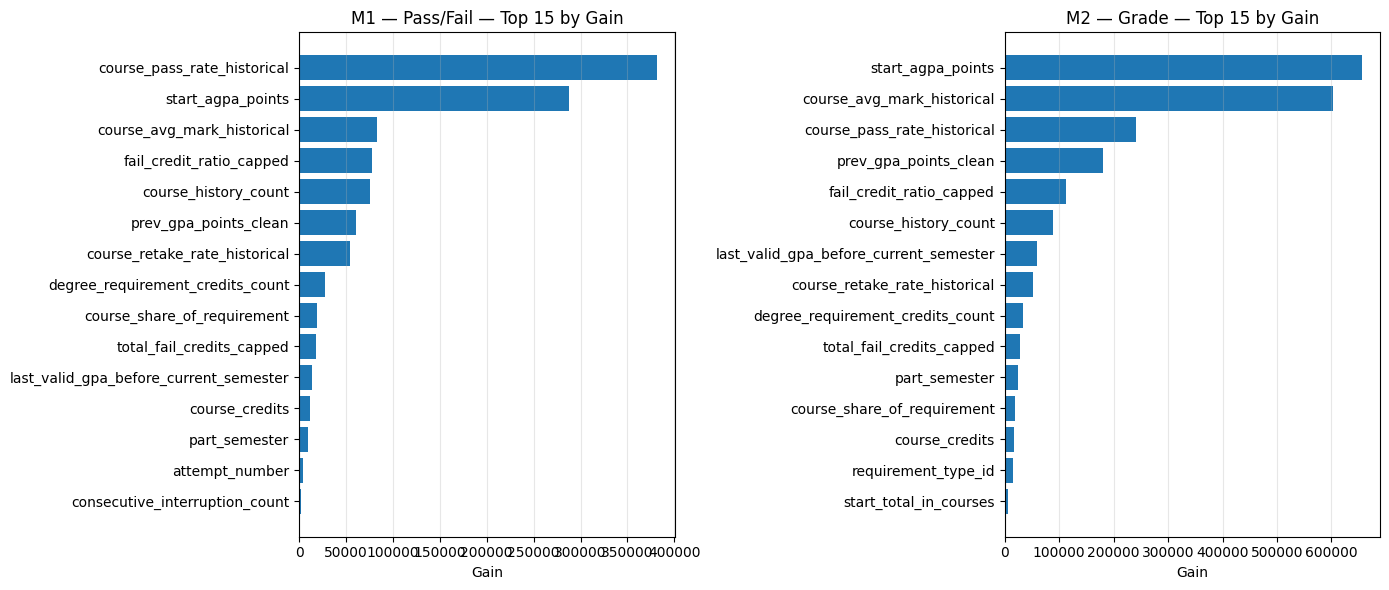

In [15]:
fi_m1 = pd.read_csv(MODELS_DIR / "m1_feature_importance.csv")
fi_m2 = pd.read_csv(MODELS_DIR / "m2_feature_importance.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fi, title in zip(axes,
                         [fi_m1, fi_m2],
                         ["M1 — Pass/Fail", "M2 — Grade"]):
    top15 = fi.nlargest(15, "gain")
    ax.barh(top15["feature"].iloc[::-1], top15["gain"].iloc[::-1])
    ax.set_title(f"{title} — Top 15 by Gain")
    ax.set_xlabel("Gain")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()